# 01 · Dataset provenance and exploratory analysis

This notebook uses the source recorded in the active model. The Hugging Face dataset is a public benchmark; its minimal card does not document how transactions were collected. Names, card numbers and identifiers are excluded. Source counts describe integrity; feature plots use training rows only.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd
from IPython.display import display, Image, Markdown
from src.dataset import load_training_frame
from src.data_processing import inspect_dataset, split_dataset, make_schema, validate_features
metadata = json.loads(Path('models/model_metadata.json').read_text())
frame, target, source = load_training_frame(Path('data/raw') / metadata['dataset']['file'])
train, validation, test = split_dataset(frame, target, metadata['training']['seed'], metadata['dataset'].get('split_strategy', 'stratified'))
features = [f['name'] for f in metadata['features']]

profile = inspect_dataset(frame, target)
print('Dataset:', source.get('dataset_id', source['name']))
print('Revision:', source.get('revision'))
print('SHA-256:', metadata['dataset']['sha256'])
print({key: profile[key] for key in ['rows', 'columns', 'class_counts', 'fraud_percentage', 'duplicate_rows']})
print('Original columns:', metadata['dataset'].get('raw_columns', list(frame)))
print('Excluded columns:', metadata['dataset'].get('excluded_columns', []))
display(pd.DataFrame({'dtype': frame.dtypes.astype(str), 'missing': frame.isna().sum()}))


Dataset: santosh3110/credit_card_fraud_transactions
Revision: 63e73d05a06e1b87ef7dd9c6092eabc46245fcac
SHA-256: 26b3b9c382c753e6cac75fb95a5ec9efe6832937a4e3fd777e6471c53a6eb490
{'rows': 1048575, 'columns': 10, 'class_counts': {'0': 1042569, '1': 6006}, 'fraud_percentage': 0.5727773406766326, 'duplicate_rows': 0}
Original columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
Excluded columns: ['Unnamed: 0', 'cc_num', 'merchant', 'first', 'last', 'gender', 'street', 'city', 'zip', 'job', 'dob', 'trans_num', 'unix_time']


,dtype,missing
Amount,float64,0
Time,float64,0
category,object,0
state,object,0
city_pop,int64,0
lat,float64,0
long,float64,0
merch_lat,float64,0
merch_long,float64,0
is_fraud,int64,0


## Class imbalance
An always-legitimate classifier can appear accurate while detecting no fraud. Report fraud-class recall, precision, F2, average precision and confusion counts.

Always-legitimate accuracy: 0.9942722265932337


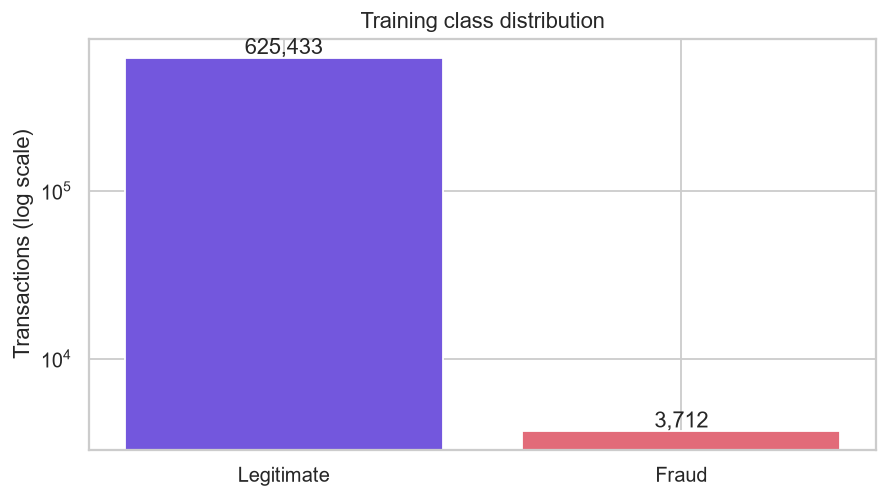

,partition,rows,fraud,legitimate,time_min,time_max
0,train,629145,3712,625433,0.0,23004900.0
1,validation,209715,1149,208566,23004960.0,29924760.0
2,test,209715,1145,208570,29924820.0,37555680.0


In [2]:
print('Always-legitimate accuracy:', 1 - frame[target].mean())
display(Image(filename='reports/eda/class_distribution.png'))
display(pd.DataFrame([{'partition': key, **value} for key, value in metadata['dataset']['splits'].items()]))


## Amount and time
Amounts use source units; a currency is not assumed when the dataset card does not specify one. Time is measured from the recorded origin, without assuming a verified local timezone. Class densities are normalized.

Amount unit: dataset units
Time origin: 2019-01-01T00:00:00


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,625433.0,67.641971,154.818556,1.00,9.6000,47.180,82.4300,26544.12
1,3712.0,519.706161,394.680549,1.18,121.5075,357.895,899.1325,1371.81


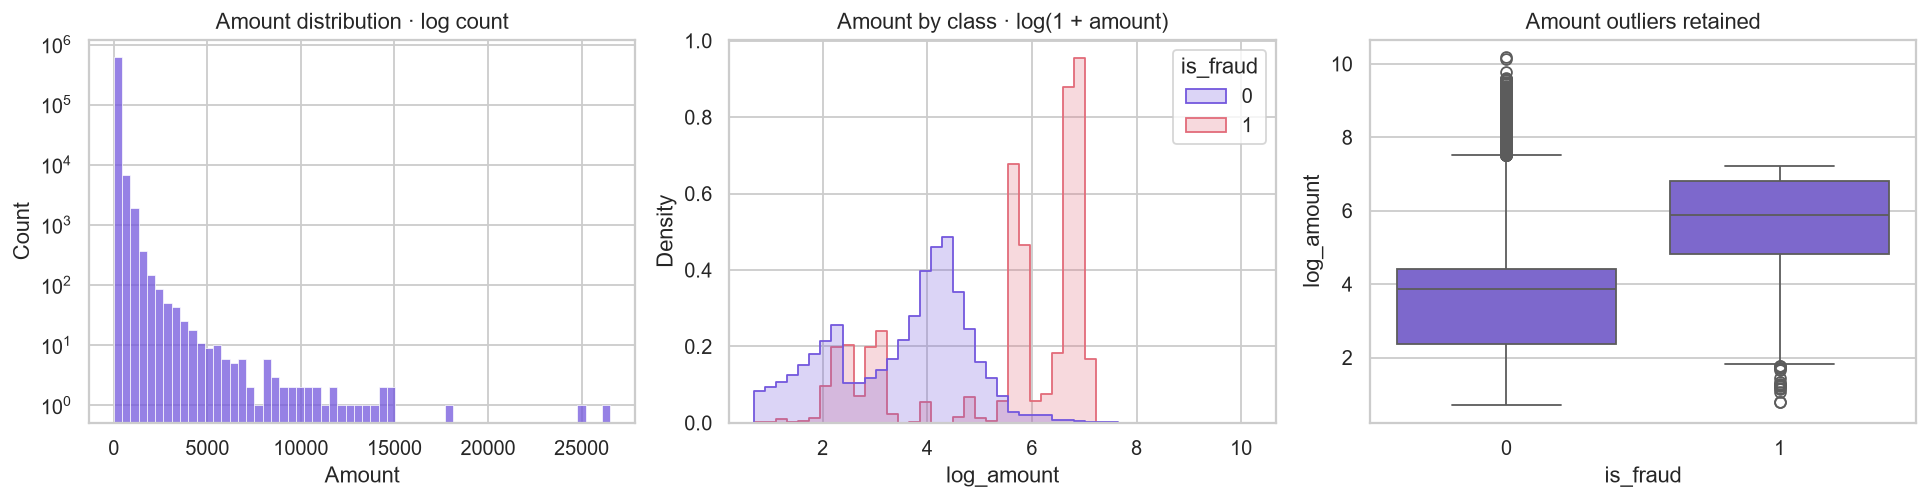

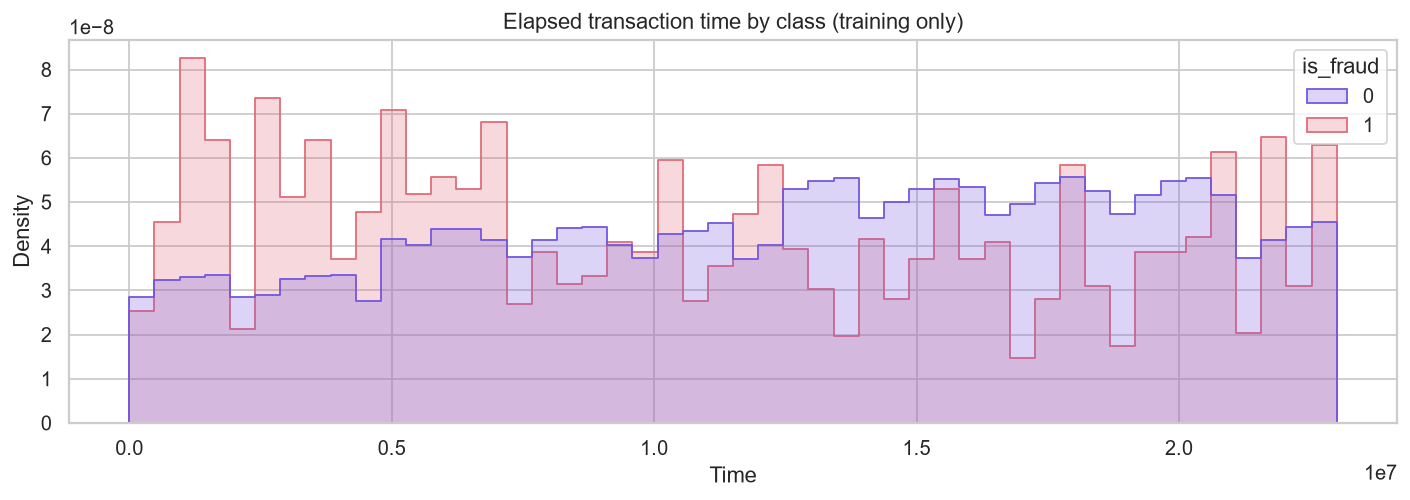

In [3]:
print('Amount unit:', metadata['dataset'].get('amount_unit'))
print('Time origin:', metadata['dataset'].get('time_origin'))
display(train.groupby(target)['Amount'].describe())
display(Image(filename='reports/eda/amount_distributions.png'))
display(Image(filename='reports/eda/time_distribution.png'))


## Correlations and numeric feature distributions
Associations are not causal explanations. All displayed feature distributions come from the training partition.

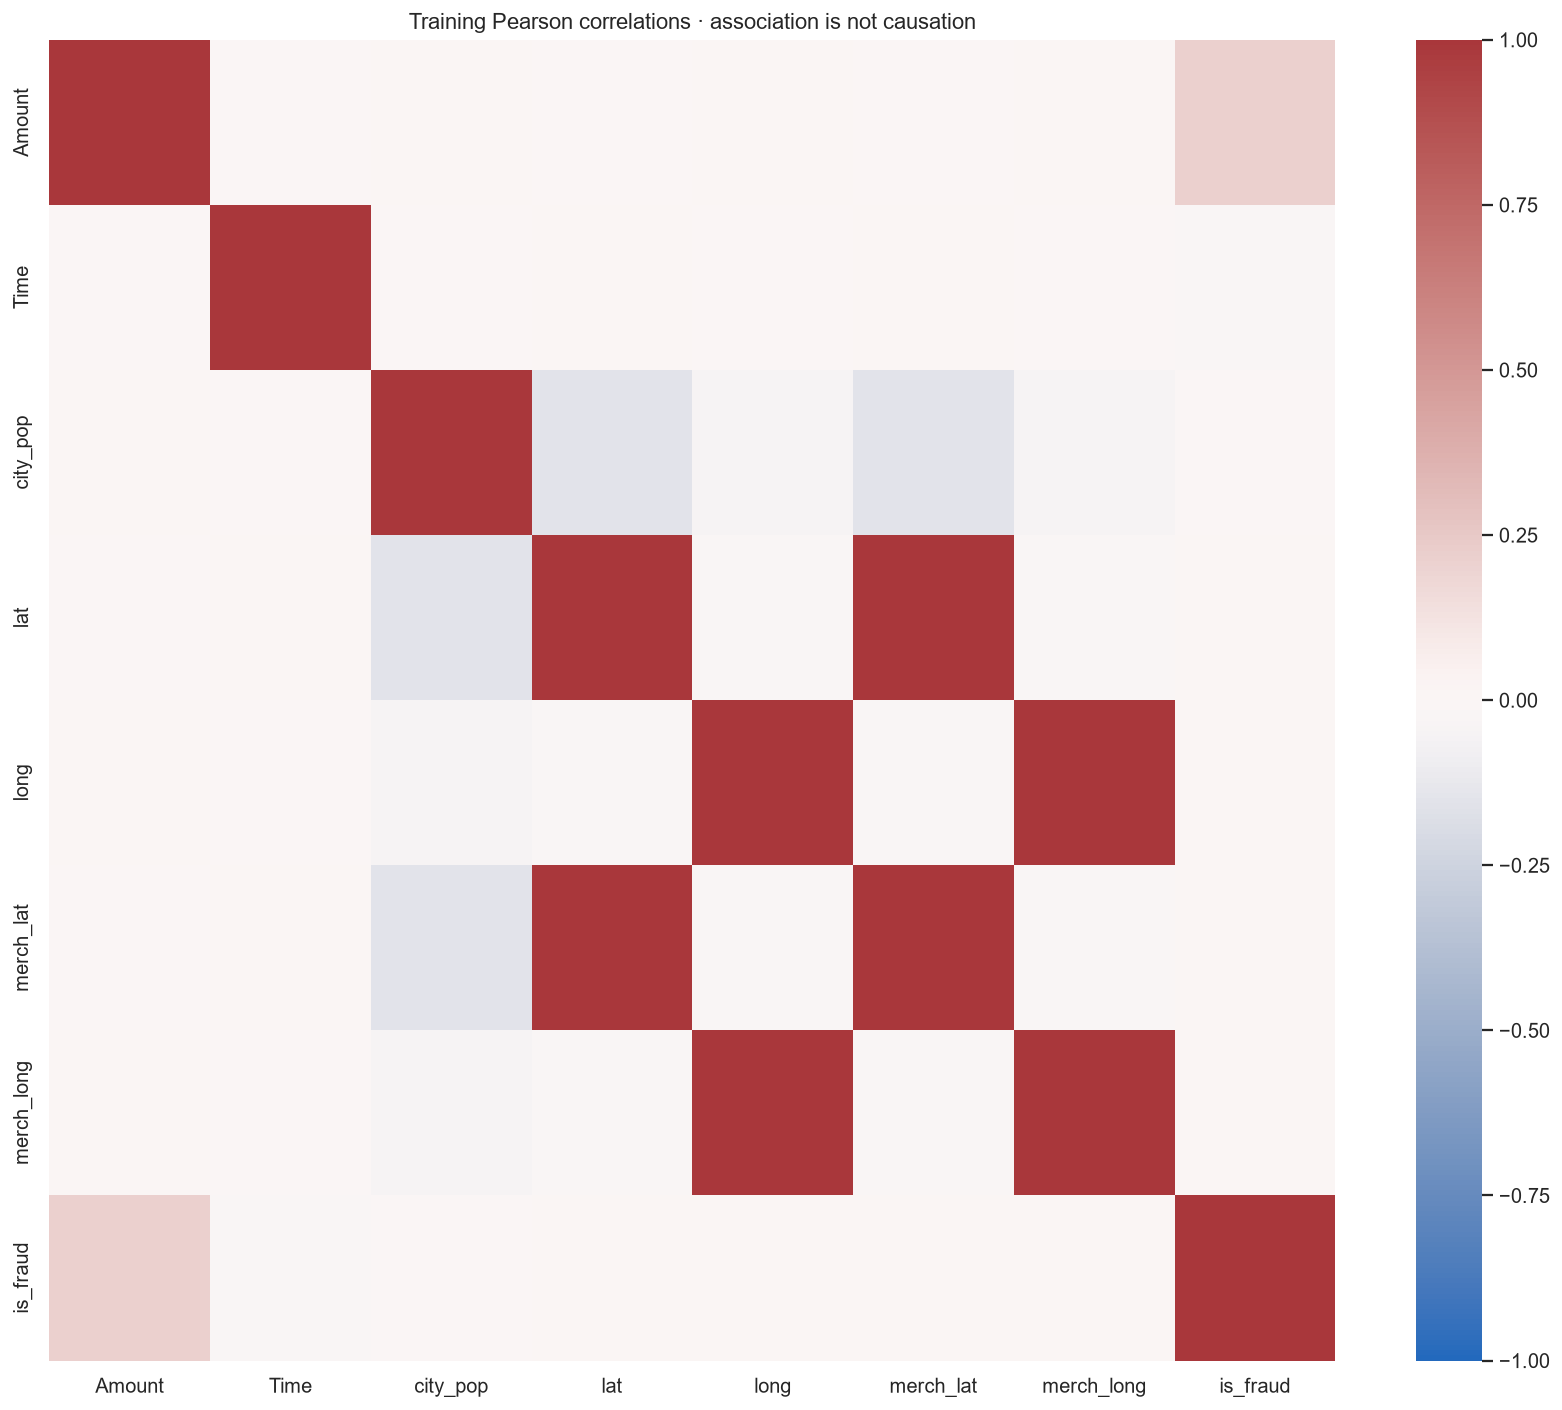

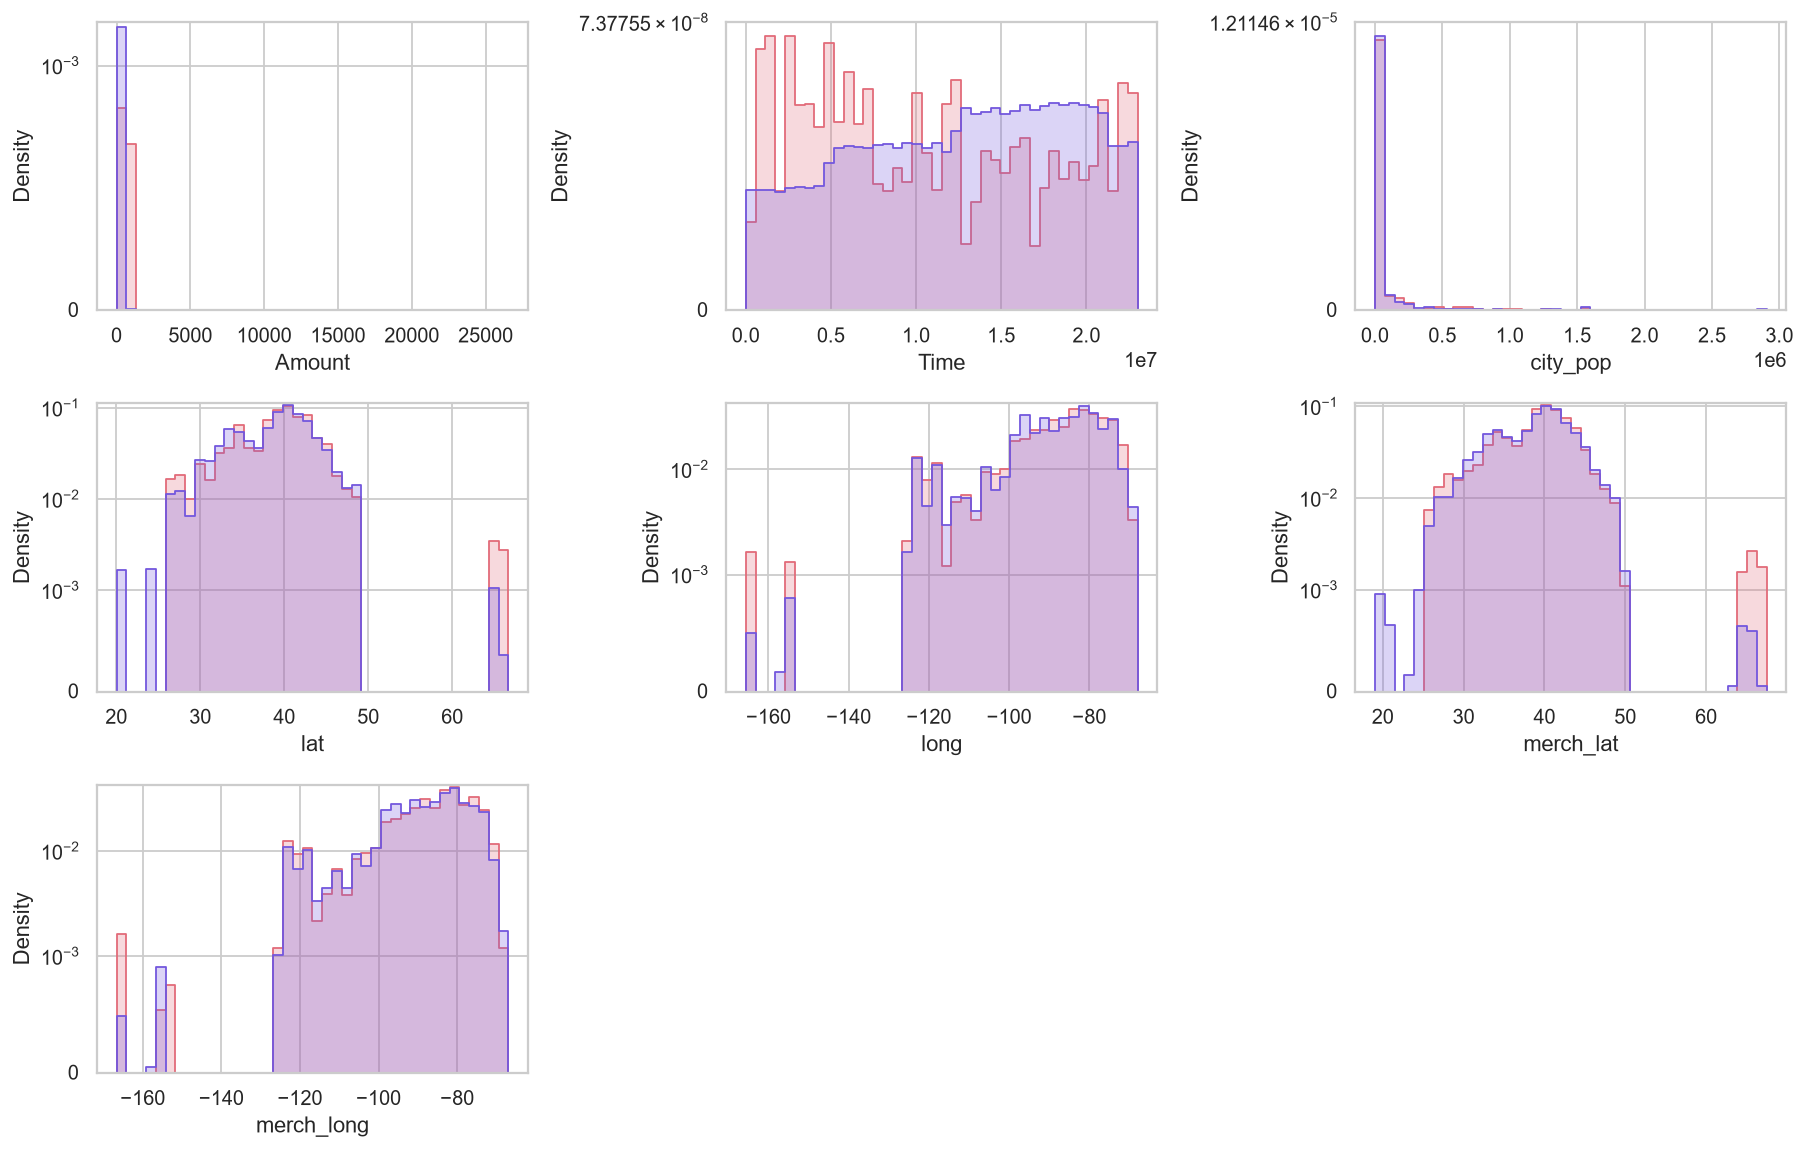

In [4]:
display(Image(filename='reports/eda/correlations.png'))
for path in sorted(Path('reports/eda').glob('feature_distributions_*.png')):
    display(Image(filename=str(path)))


## Outliers and limitations
Outliers are retained because unusual transactions may carry fraud signal. Chronological evaluation measures later transactions, not unseen customers: customers can recur across windows. This benchmark does not establish real-world payment performance.

In [5]:
eda = json.loads(Path('reports/eda/eda.json').read_text())
display(pd.Series(eda['iqr_outlier_counts'], name='IQR outliers').sort_values(ascending=False).to_frame())
display(Markdown(Path('reports/eda/findings.md').read_text()))


,IQR outliers
city_pop,117925
Amount,32657
long,24340
merch_long,20435
is_fraud,3712
merch_lat,2427
lat,2276
Time,0


# Dataset and EDA findings

The source fraud prevalence is 0.5728%; always predicting legitimate would look accurate.

0 exact duplicate rows are removed before splitting to avoid overlap.

No outlier rows are discarded: rare extremes can be useful fraud signals. Robust scaling and log amount reduce scale sensitivity.

Transaction category, amount and location signals are modeled. Names, card numbers and record identifiers are excluded.

Time is elapsed seconds from the configured source origin, not a verified local timezone.

Chronological train/validation/test windows evaluate later transactions; timestamps tied at boundaries stay together. Customers can recur across windows, so this is not an unseen-customer benchmark.

All distribution and correlation charts use only the training partition.
